Epoch 1/10 - train_loss: 0.3061 - val_loss: 0.2068 - Dice: 0.6960 - IoU: 0.5564 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999
Epoch 2/10 - train_loss: 0.1628 - val_loss: 0.1762 - Dice: 0.6271 - IoU: 0.4845 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999


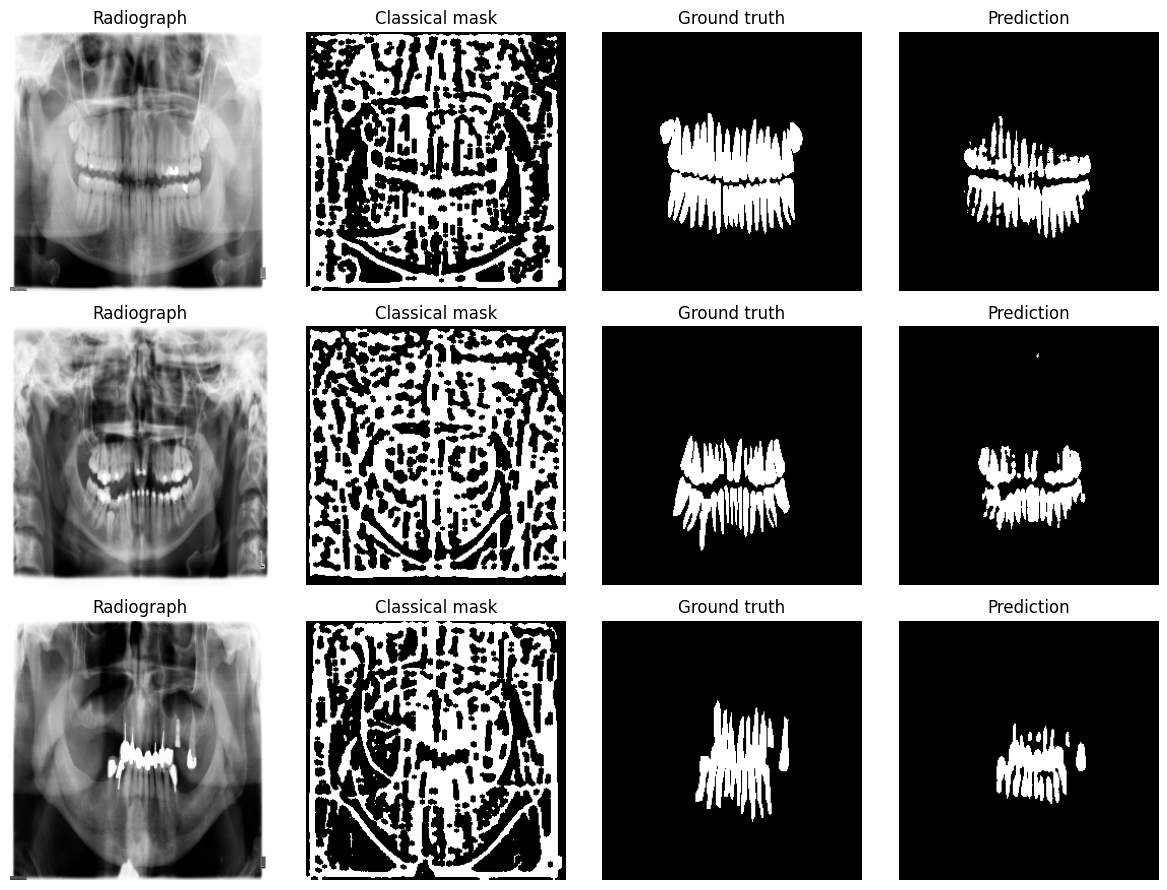

Epoch 3/10 - train_loss: 0.1179 - val_loss: 0.1291 - Dice: 0.7621 - IoU: 0.6367 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999
Epoch 4/10 - train_loss: 0.0989 - val_loss: 0.0891 - Dice: 0.8113 - IoU: 0.7056 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999


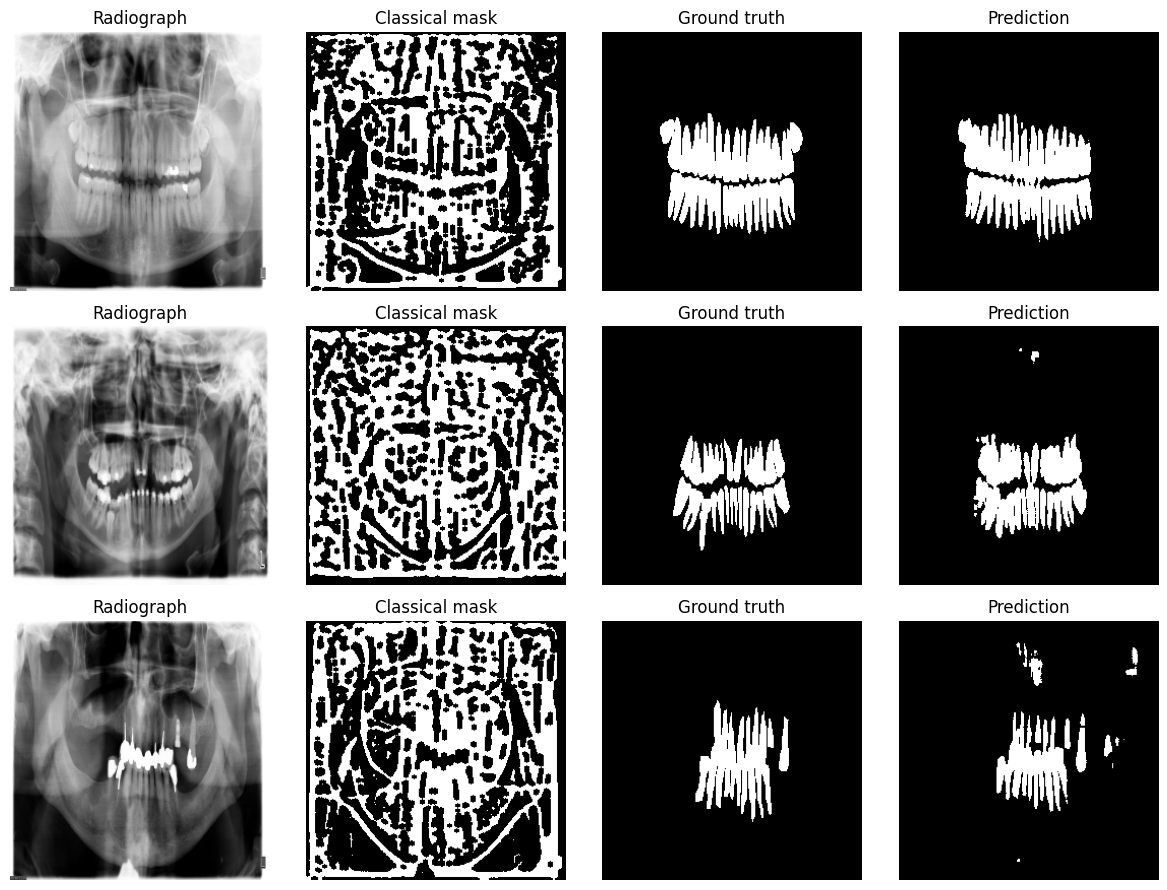

Epoch 5/10 - train_loss: 0.0873 - val_loss: 0.0840 - Dice: 0.8165 - IoU: 0.7120 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999
Epoch 6/10 - train_loss: 0.0780 - val_loss: 0.0865 - Dice: 0.8144 - IoU: 0.7068 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999


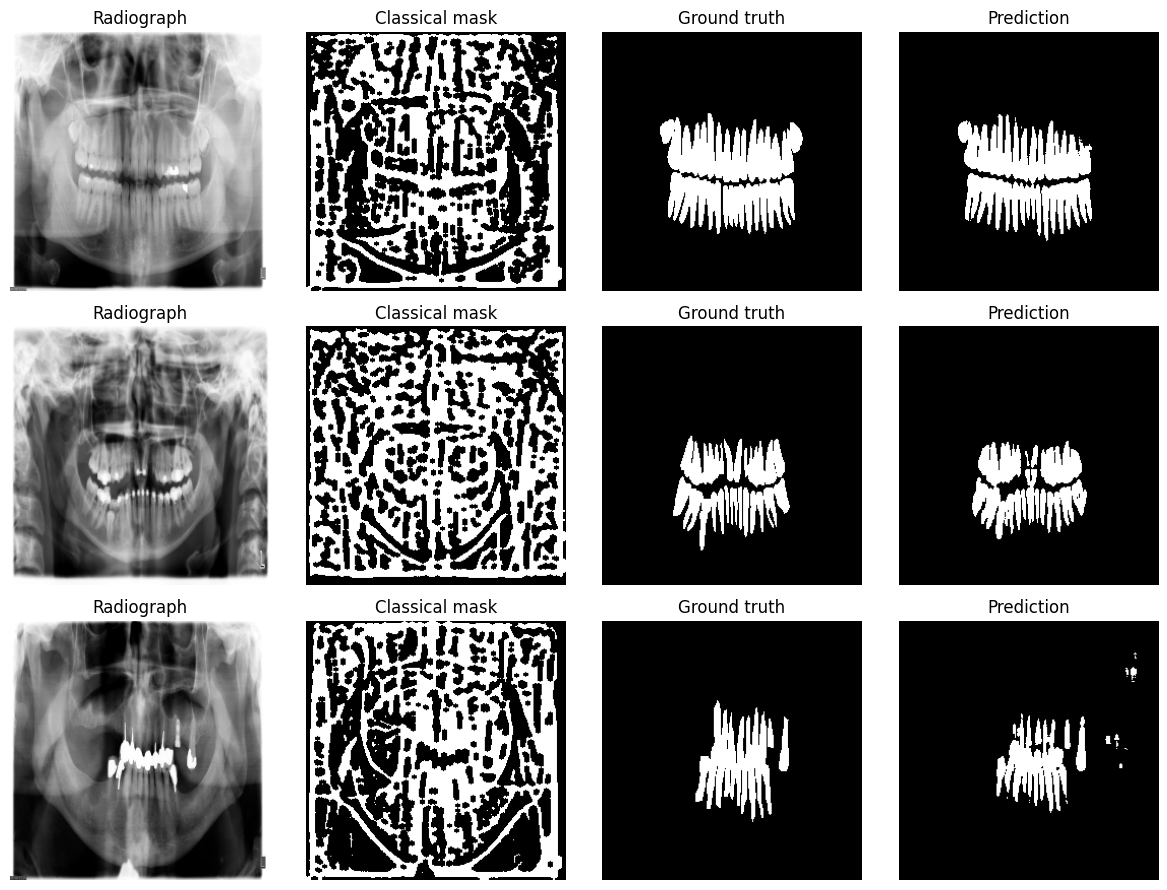

Epoch 7/10 - train_loss: 0.0753 - val_loss: 0.0752 - Dice: 0.8317 - IoU: 0.7352 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999
Epoch 8/10 - train_loss: 0.0720 - val_loss: 0.0677 - Dice: 0.8449 - IoU: 0.7529 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999


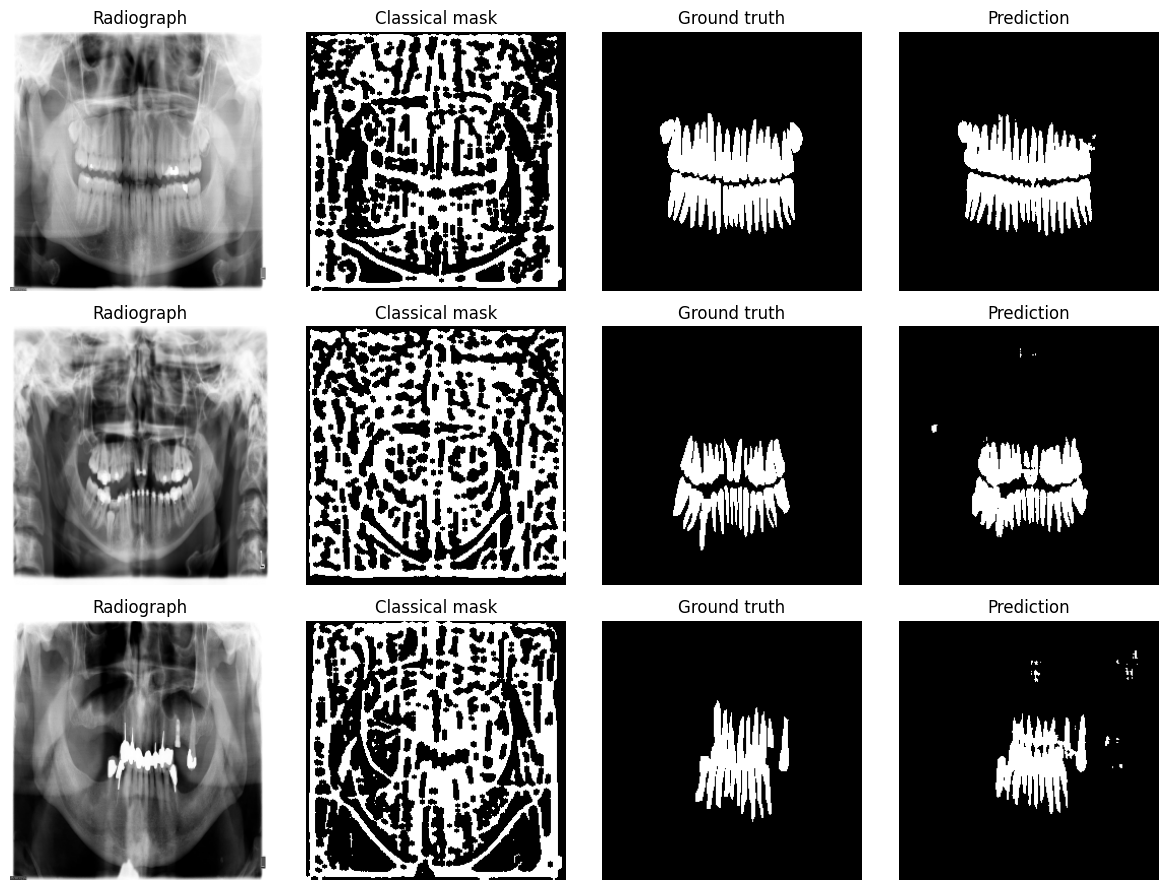

Epoch 9/10 - train_loss: 0.0689 - val_loss: 0.0669 - Dice: 0.8508 - IoU: 0.7611 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999
Epoch 10/10 - train_loss: 0.0652 - val_loss: 0.0674 - Dice: 0.8474 - IoU: 0.7559 - Baseline Dice: 0.1796 - Baseline IoU: 0.0999


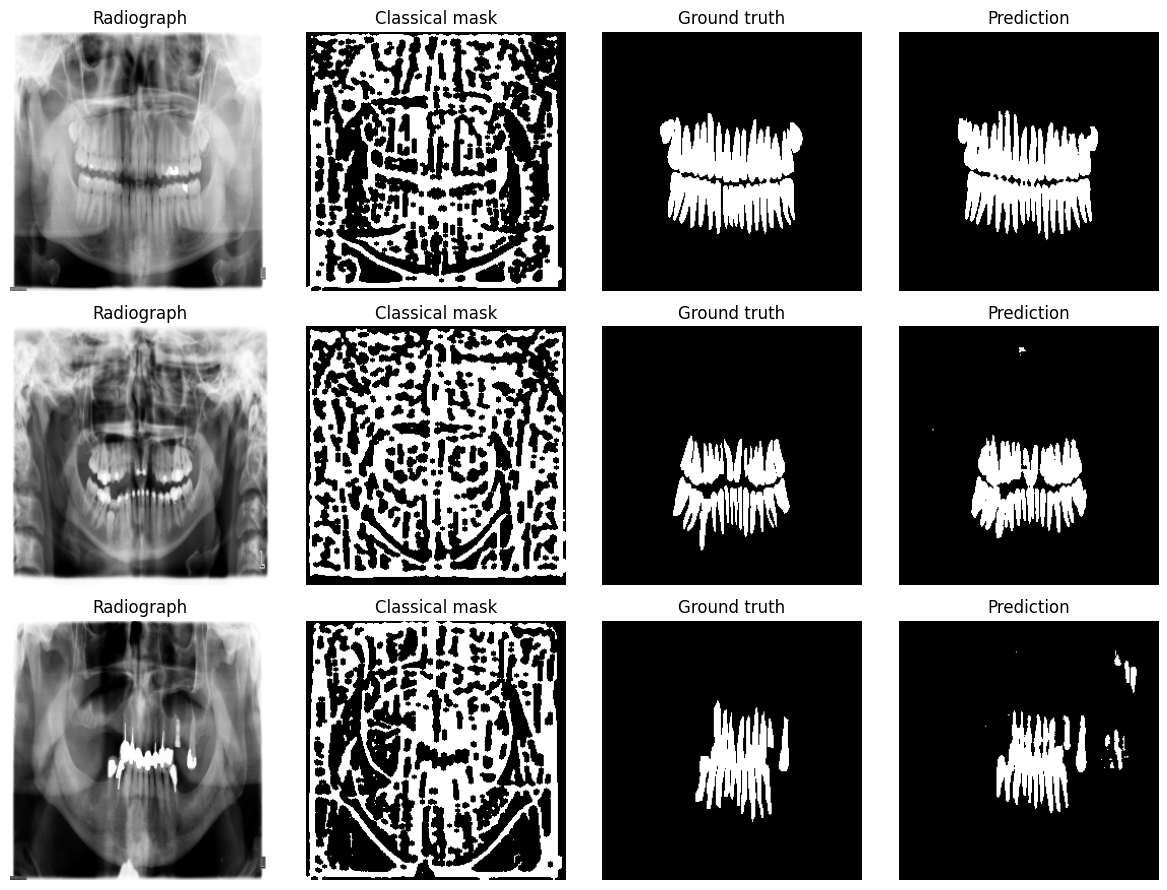

In [7]:
import os
import glob
import random

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

def get_feature_detector():
    if hasattr(cv2, "SIFT_create"):
        return cv2.SIFT_create()
    if hasattr(cv2, "ORB_create"):
        return cv2.ORB_create()
    return cv2.FastFeatureDetector_create()

def generate_classical_mask(image, size=(256, 256)):
    if image.shape[:2] != size:
        image = cv2.resize(image, size, interpolation=cv2.INTER_AREA)
    blur = cv2.GaussianBlur(image, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(
        blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    return mask.astype(np.float32) / 255.0

def feature_keypoint_heatmap(image, size=(256, 256), detector=None):
    if detector is None:
        detector = get_feature_detector()
    if image.shape[:2] != size:
        image = cv2.resize(image, size, interpolation=cv2.INTER_AREA)
    keypoints = detector.detect(image, None)
    heatmap = np.zeros(image.shape, dtype=np.uint8)
    for kp in keypoints:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        cv2.circle(heatmap, (x, y), 4, 255, -1)
    heatmap = cv2.GaussianBlur(heatmap, (7, 7), 0)
    return heatmap.astype(np.float32) / 255.0

def build_hybrid_input(image, size=(256, 256), detector=None):
    image_float = image.astype(np.float32) / 255.0
    classical_mask = generate_classical_mask(image, size=size)
    heatmap = feature_keypoint_heatmap(image, size=size, detector=detector)
    return np.stack([image_float, classical_mask, heatmap], axis=0)

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class TeethSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=(256, 256), feature_mode="hybrid"):
        self.size = size
        self.feature_mode = feature_mode
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.*")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.*")))
        self.mask_map = {
            os.path.splitext(os.path.basename(p))[0]: p
            for p in self.mask_paths
        }
        self.samples = []
        for img_path in self.image_paths:
            key = os.path.splitext(os.path.basename(img_path))[0]
            mask_path = self.mask_map.get(key)
            if mask_path:
                self.samples.append((img_path, mask_path))

        self.detector = get_feature_detector()
        self.input_channels = self._infer_input_channels()

    def _infer_input_channels(self):
        if self.feature_mode == "none":
            return 1
        if self.feature_mode == "classical":
            return 2
        if self.feature_mode in {"keypoint", "sift", "orb"}:
            return 2
        return 3

    def __len__(self):
        return len(self.samples)

    def _build_input_tensor(self, image):
        image_float = image.astype(np.float32) / 255.0
        classical_mask = generate_classical_mask(image, size=self.size)

        channels = [image_float]
        if self.feature_mode in {"classical", "hybrid"}:
            channels.append(classical_mask)

        if self.feature_mode in {"hybrid", "keypoint", "sift", "orb"}:
            heatmap = feature_keypoint_heatmap(image, size=self.size, detector=self.detector)
            channels.append(heatmap)

        return np.stack(channels, axis=0), classical_mask

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        image = cv2.resize(image, self.size, interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, self.size, interpolation=cv2.INTER_NEAREST)

        input_tensor, classical_mask = self._build_input_tensor(image)
        target_tensor = (mask > 127).astype(np.float32)[np.newaxis, ...]

        return (
            torch.from_numpy(input_tensor),
            torch.from_numpy(target_tensor),
            torch.from_numpy(classical_mask[np.newaxis, ...].astype(np.float32)),
        )


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 16)
        self.enc2 = DoubleConv(16, 32)
        self.enc3 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = DoubleConv(64, 32)
        self.dec1 = DoubleConv(32, 16)
        self.out_conv = nn.Conv2d(16, out_channels, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        x3 = self.enc3(self.pool(x2))

        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dec1(x)

        return self.out_conv(x)


def dice_coef(pred, target, eps=1e-6):
    num = 2 * (pred * target).sum(dim=(1, 2, 3))
    denom = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((num + eps) / (denom + eps)).mean().item()


def iou_score(pred, target, eps=1e-6):
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()


def visualize_batch(inputs, classical_masks, targets, preds, n=3):
    fig, axes = plt.subplots(n, 4, figsize=(12, 3 * n))
    for i in range(n):
        axes[i, 0].imshow(inputs[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 0].set_title("Radiograph")
        axes[i, 1].imshow(classical_masks[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 1].set_title("Classical mask")
        axes[i, 2].imshow(targets[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 2].set_title("Ground truth")
        axes[i, 3].imshow(preds[i, 0].cpu().numpy(), cmap="gray")
        axes[i, 3].set_title("Prediction")
        for j in range(4):
            axes[i, j].axis("off")
    plt.tight_layout()
    plt.show()

data_dir = "."
image_dir = os.path.join(data_dir, "Radiographs")
mask_dir = os.path.join(data_dir, "Segmentation", "teeth_mask")
feature_mode = "hybrid"

dataset = TeethSegmentationDataset(image_dir, mask_dir, size=(256, 256), feature_mode=feature_mode)

train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

if len(dataset) == 0:
    train_dataset = dataset
    val_dataset = dataset
    
else:
    train_size = int(len(dataset) * 0.8)
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True, num_workers=1, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=6, shuffle=False, num_workers=1, pin_memory=True)

model = SimpleUNet(in_channels=dataset.input_channels, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

epochs = 10
for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for x, y, _ in train_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    dices = []
    ious = []
    baseline_dices = []
    baseline_ious = []
    with torch.no_grad():
        for x, y, cls_mask in val_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            dices.append(dice_coef(preds, y))
            ious.append(iou_score(preds, y))

            baseline_preds = (cls_mask > 0.5).float().to(device)
            baseline_dices.append(dice_coef(baseline_preds, y))
            baseline_ious.append(iou_score(baseline_preds, y))

    val_loss /= len(val_loader.dataset)
    avg_dice = sum(dices) / len(dices) if dices else 0.0
    avg_iou = sum(ious) / len(ious) if ious else 0.0
    avg_baseline_dice = sum(baseline_dices) / len(baseline_dices) if baseline_dices else 0.0
    avg_baseline_iou = sum(baseline_ious) / len(baseline_ious) if baseline_ious else 0.0

    print(
        f"Epoch {epoch}/{epochs} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} "
        f"- Dice: {avg_dice:.4f} - IoU: {avg_iou:.4f} "
        f"- Baseline Dice: {avg_baseline_dice:.4f} - Baseline IoU: {avg_baseline_iou:.4f}"
    )

    if epoch == epochs or epoch % 2 == 0:
        x_vis, y_vis, cls_vis = next(iter(val_loader))
        x_vis = x_vis.to(device)
        with torch.no_grad():
            out_vis = torch.sigmoid(model(x_vis))
            pred_vis = (out_vis > 0.5).float()
        visualize_batch(
            x_vis.cpu(),
            cls_vis,
            y_vis,
            pred_vis.cpu(),
            n=min(3, x_vis.size(0)),
        )